In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns

In [58]:
df= pd.read_csv(r"C:\Users\LalithaMohan\Downloads\Walmart\Walmart DataSet.csv")

In [59]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.set_index('Date')

In [60]:
df1=df[df['Store']==1]
df1=df1.drop(['Store','Holiday_Flag',
'Temperature','Fuel_Price','CPI','Unemployment'], axis=1)

In [61]:
df2=df[df['Store']==1]
df2=df2.drop(['Store','Holiday_Flag',
'Temperature','Fuel_Price','CPI','Unemployment'], axis=1)

In [62]:
df3=df[df['Store']==1]
df3=df3.drop(['Store','Holiday_Flag',
'Temperature','Fuel_Price','CPI','Unemployment'], axis=1)

In [63]:
df4=df[df['Store']==1]
df4=df4.drop(['Store','Holiday_Flag',
'Temperature','Fuel_Price','CPI','Unemployment'], axis=1)

In [64]:
df5=df[df['Store']==1]
df5=df5.drop(['Store','Holiday_Flag',
'Temperature','Fuel_Price','CPI','Unemployment'], axis=1)

Store 1


<Axes: xlabel='Date'>

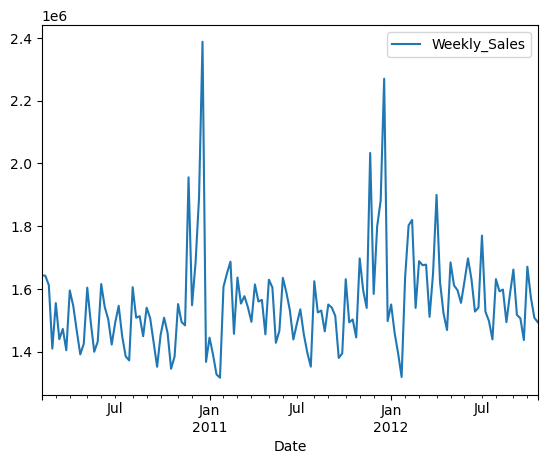

In [65]:
df1.plot()

In [66]:
df1.index.freq


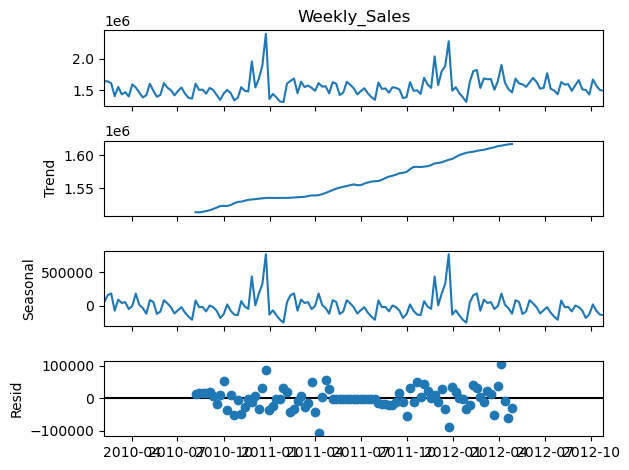

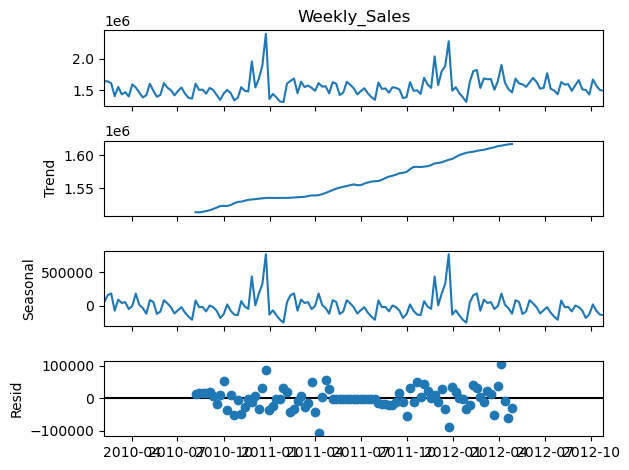

In [67]:
from statsmodels.tsa.seasonal import seasonal_decompose
ts = df1['Weekly_Sales']  

decomposed1 = seasonal_decompose(ts, model='additive', period=52)
decomposed1.plot()

In [68]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df1['Weekly_Sales'])
result[1]

1.3877788330759535e-05

In [69]:
1.3877788330759535e-05 < 0.5

True

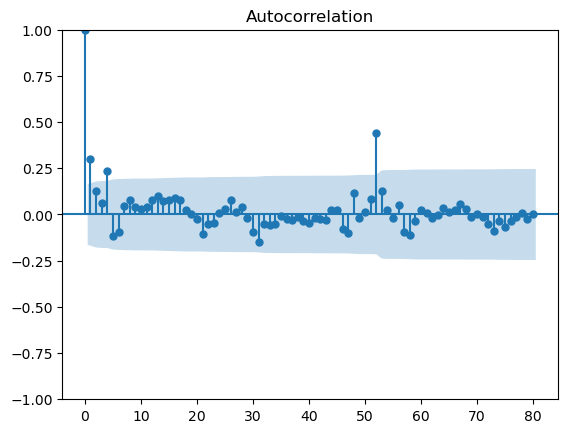

In [70]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df1[1:],lags=80);

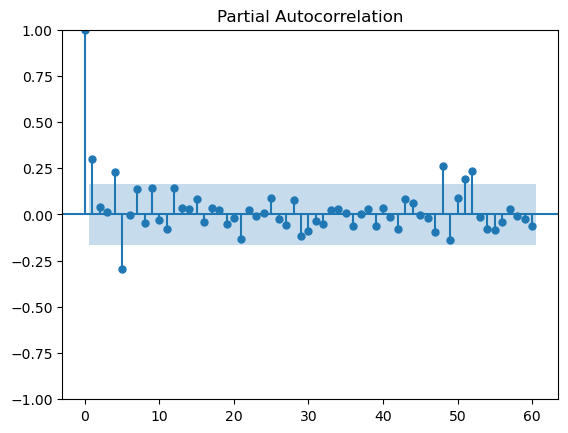

In [71]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt
plot_pacf(df1['Weekly_Sales'], lags=60)
plt.show()



In [ ]:


df1_train=df1[0:113]
df1_test=df1[114:]

In [73]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df1['Weekly_Sales'], order=(1,0,1))
results = model.fit()

print(results.summary())


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1905.383
Date:                Mon, 24 Nov 2025   AIC                           3818.767
Time:                        20:50:49   BIC                           3830.618
Sample:                    02-05-2010   HQIC                          3823.583
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.555e+06   2.24e+04     69.381      0.000    1.51e+06     1.6e+06
ar.L1          0.4740      0.313      1.517      0.129      -0.139       1.087
ma.L1         -0.1934      0.361     -0.536      0.5

c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [74]:
fore1 = results.forecast(steps=10)
print(fore1)


2012-11-02    1.535786e+06
2012-11-09    1.546032e+06
2012-11-16    1.550888e+06
2012-11-23    1.553190e+06
2012-11-30    1.554281e+06
2012-12-07    1.554798e+06
2012-12-14    1.555044e+06
2012-12-21    1.555160e+06
2012-12-28    1.555215e+06
2013-01-04    1.555241e+06
Freq: W-FRI, Name: predicted_mean, dtype: float64


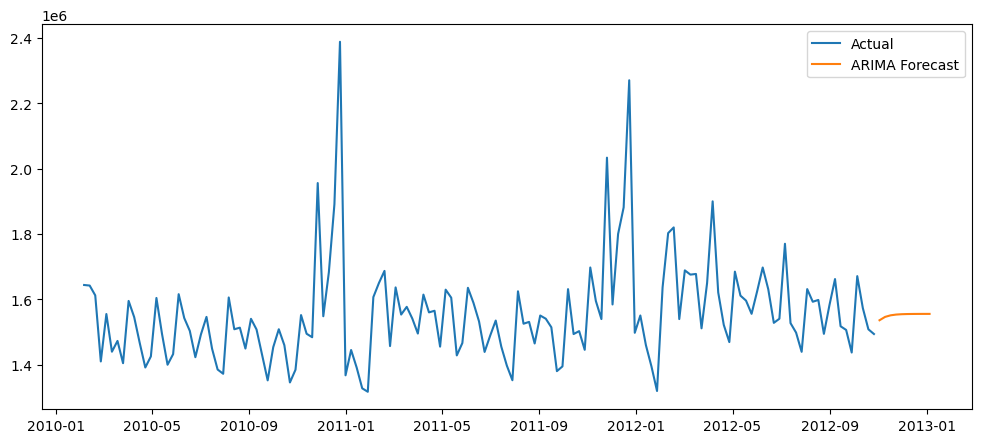

In [75]:
plt.figure(figsize=(12,5))
plt.plot(df1.index, df1['Weekly_Sales'], label='Actual')
plt.plot(fore1.index, fore1, label='ARIMA Forecast')
plt.legend()
plt.show()


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


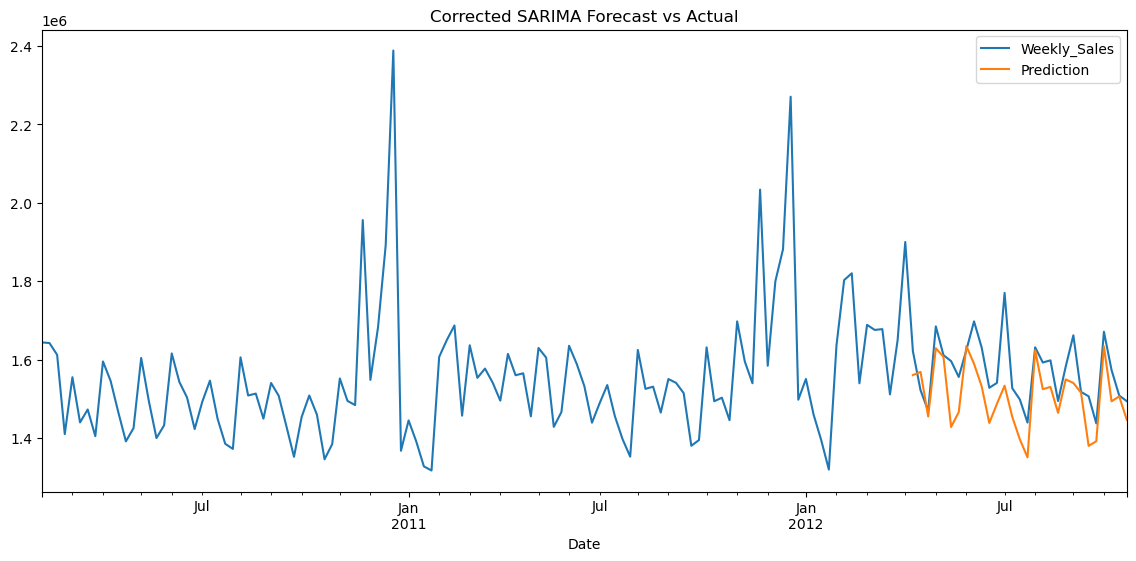

In [ ]:



from statsmodels.tsa.statespace.sarimax import SARIMAX


model = SARIMAX(df1_train['Weekly_Sales'],
                order=(1,0,1),
                seasonal_order=(0,1,1,52))
model_fit = model.fit()


start = df1_test.index[0]
end   = df1_test.index[-1]

test_predictions = model_fit.predict(start=start, end=end, dynamic=False)


df_pred = df1.copy()
df_pred["Prediction"] = None
df_pred.loc[df1_test.index, "Prediction"] = test_predictions


df_pred[['Weekly_Sales', 'Prediction']].plot(figsize=(14,6))
plt.title("Corrected SARIMA Forecast vs Actual")
plt.show()


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


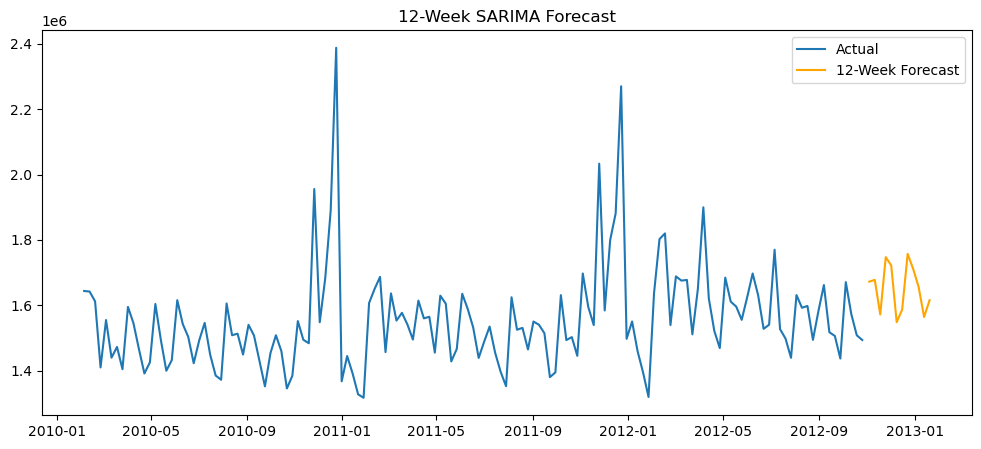

In [ ]:



models = SARIMAX(df1['Weekly_Sales'],
                order=(1,0,1),
                seasonal_order=(0,1,1,52))
models_fit = model.fit()


forecast = models_fit.forecast(steps=12)


future_dates = pd.date_range(start=df1.index[-1], periods=13, freq='W')[1:]
forecast.index = future_dates


plt.figure(figsize=(12,5))
plt.plot(df1['Weekly_Sales'], label='Actual')
plt.plot(forecast, label='12-Week Forecast', color='orange')
plt.title("12-Week SARIMA Forecast")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_true = df1_test['Weekly_Sales']
y_pred = test_predictions 

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")


RMSE: 85979.42, MAE: 75789.05, MAPE: 4.85%


Store 2


<Axes: xlabel='Date'>

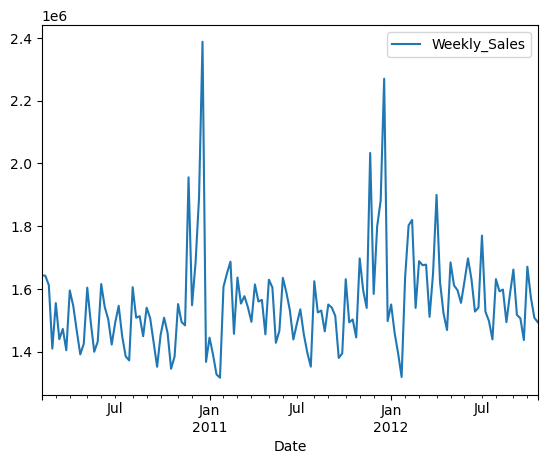

In [78]:
df2.plot()


In [79]:
df1.index.freq


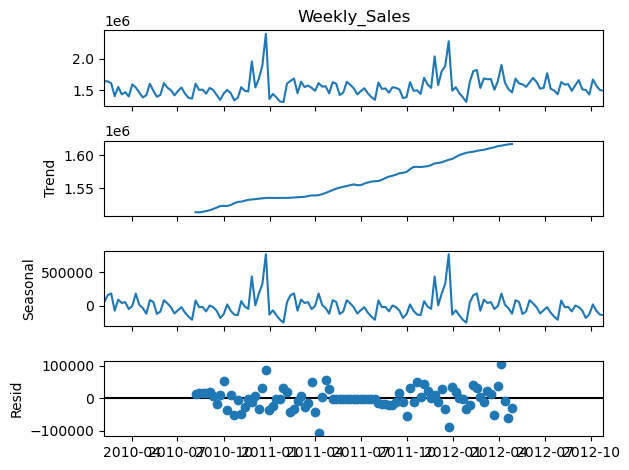

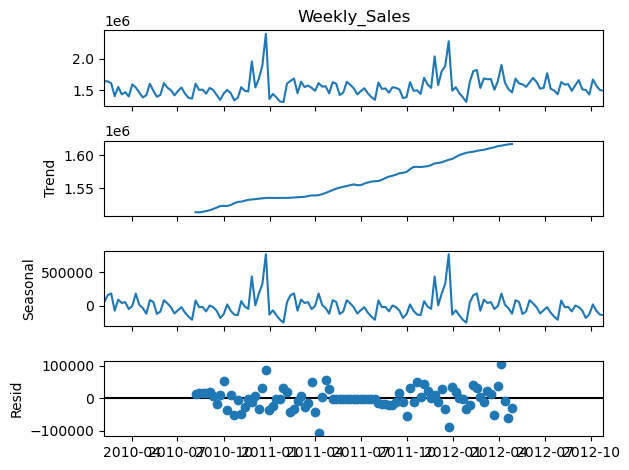

In [80]:
from statsmodels.tsa.seasonal import seasonal_decompose
ts = df2['Weekly_Sales']  

decomposed1 = seasonal_decompose(ts, model='additive', period=52)
decomposed1.plot()

In [81]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df1['Weekly_Sales'])
result[1]

1.3877788330759535e-05

In [82]:
1.3877788330759535e-05 < 0.5

True

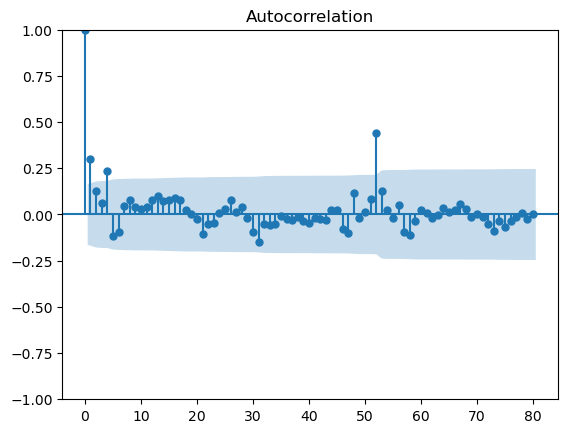

In [83]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df2[1:],lags=80);

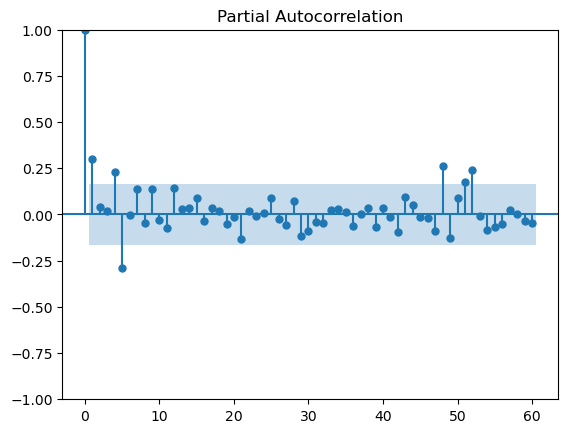

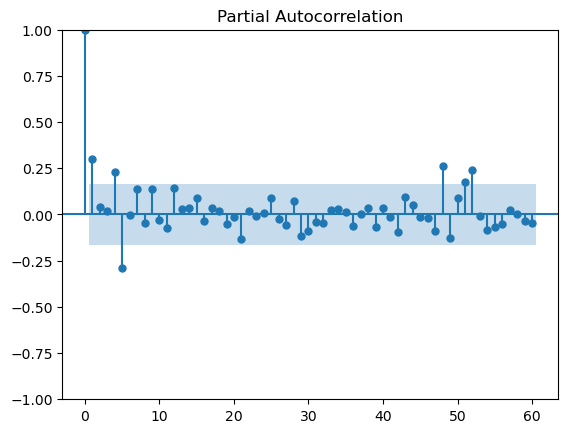

In [84]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df2[1:],lags=60)

In [85]:


df2_train=df1[0:114]
df2_test=df1[114:]

In [86]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df1['Weekly_Sales'], order=(1,0,1))
results = model.fit()

print(results.summary())


                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1905.383
Date:                Mon, 24 Nov 2025   AIC                           3818.767
Time:                        20:50:58   BIC                           3830.618
Sample:                    02-05-2010   HQIC                          3823.583
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.555e+06   2.24e+04     69.381      0.000    1.51e+06     1.6e+06
ar.L1          0.4740      0.313      1.517      0.129      -0.139       1.087
ma.L1         -0.1934      0.361     -0.536      0.5

c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


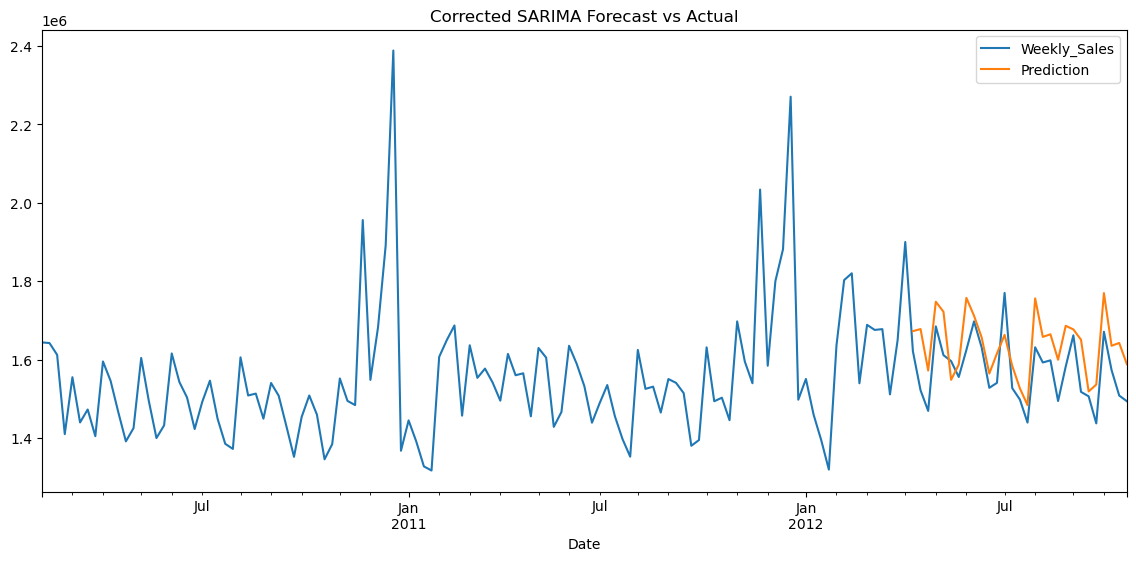

In [87]:


model = SARIMAX(df2_train,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                trend='t')

model_fit = model.fit()


start = df2_test.index[0]
end   = df2_test.index[-1]

test_predictions = model_fit.predict(start=start, end=end, dynamic=True)


df_pred = df2.copy()
df_pred["Prediction"] = None
df_pred.loc[df1_test.index, "Prediction"] = test_predictions


df_pred[['Weekly_Sales', 'Prediction']].plot(figsize=(14,6))
plt.title("Corrected SARIMA Forecast vs Actual")
plt.show()


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


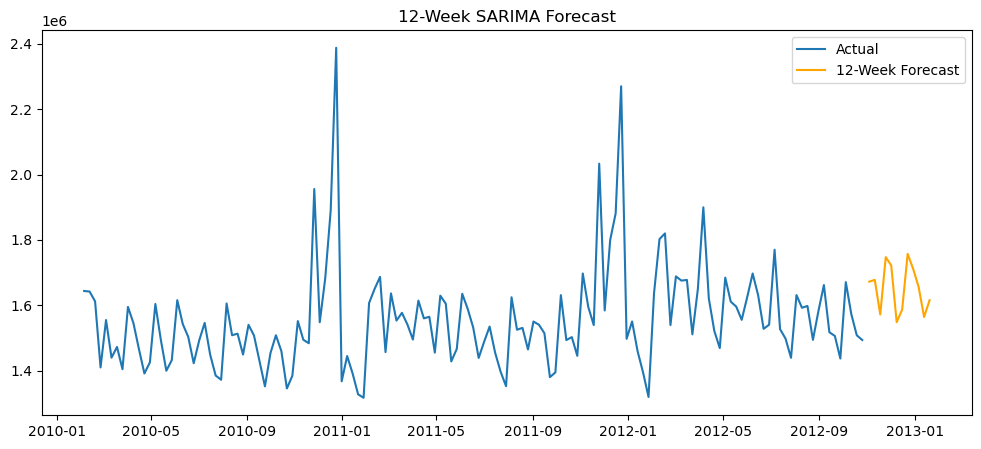

In [ ]:



models = SARIMAX(df2['Weekly_Sales'],
                order=(1,0,1),
                seasonal_order=(0,1,1,52))
models_fit = model.fit()


forecast = models_fit.forecast(steps=12)


future_dates = pd.date_range(start=df1.index[-1], periods=13, freq='W')[1:]
forecast.index = future_dates


plt.figure(figsize=(12,5))
plt.plot(df1['Weekly_Sales'], label='Actual')
plt.plot(forecast, label='12-Week Forecast', color='orange')
plt.title("12-Week SARIMA Forecast")
plt.legend()
plt.show()


Store 3

<Axes: xlabel='Date'>

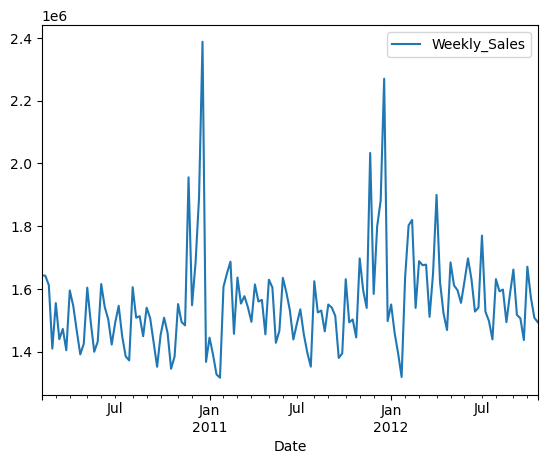

In [88]:
df3.plot()

In [89]:
result=adfuller(df3['Weekly_Sales'])
result[1]

1.3877788330759535e-05

In [90]:
1.3877788330759535e-05 < 0.5

True

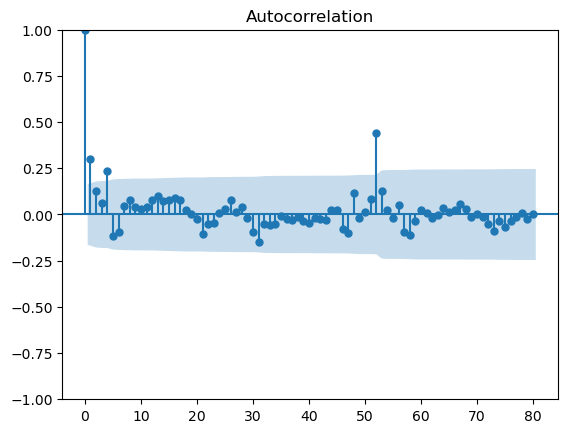

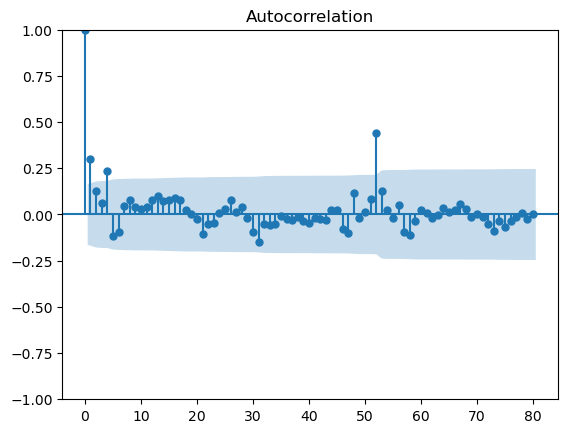

In [91]:
plot_acf(df3[1:],lags=80)

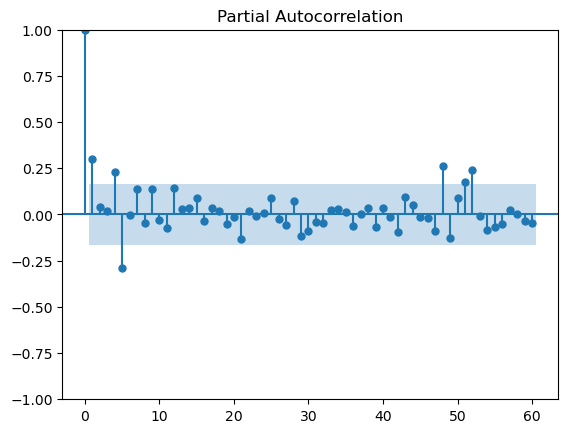

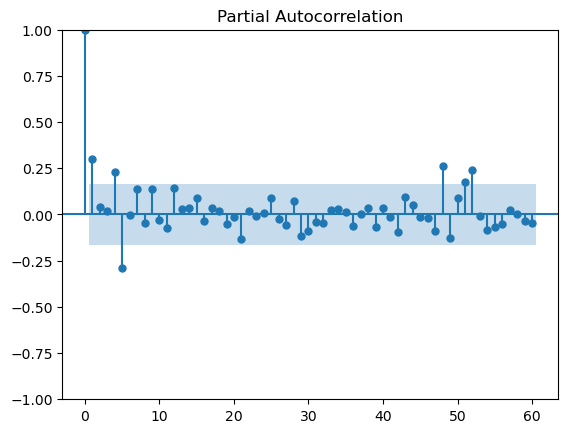

In [92]:
plot_pacf(df3[1:],lags=60)

In [93]:


df3_train=df1[0:114]
df3_test=df1[114:]

c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


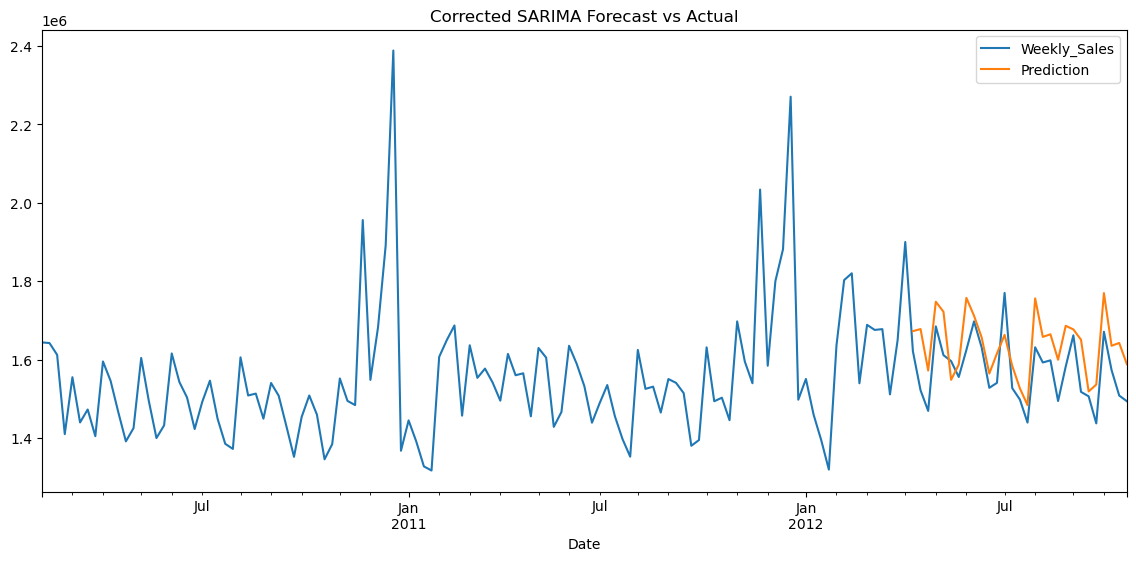

In [94]:


model = SARIMAX(df3_train,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                trend='t')

model_fit = model.fit()


start = df3_test.index[0]
end   = df3_test.index[-1]

test_predictions = model_fit.predict(start=start, end=end, dynamic=True)


df_pred = df3.copy()
df_pred["Prediction"] = None
df_pred.loc[df1_test.index, "Prediction"] = test_predictions


df_pred[['Weekly_Sales', 'Prediction']].plot(figsize=(14,6))
plt.title("Corrected SARIMA Forecast vs Actual")
plt.show()


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


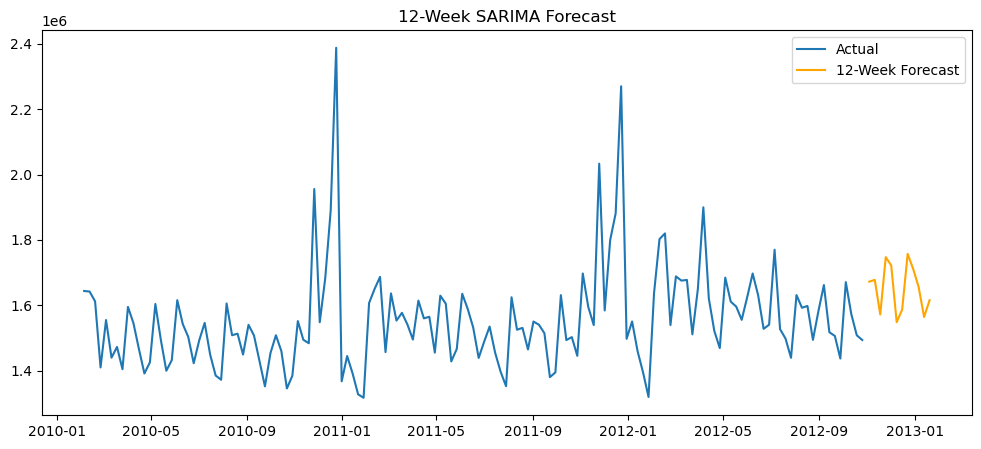

In [ ]:



models = SARIMAX(df1['Weekly_Sales'],
                order=(1,0,1),
                seasonal_order=(0,1,1,52))
models_fit = model.fit()


forecast = models_fit.forecast(steps=12)


future_dates = pd.date_range(start=df1.index[-1], periods=13, freq='W')[1:]
forecast.index = future_dates


plt.figure(figsize=(12,5))
plt.plot(df1['Weekly_Sales'], label='Actual')
plt.plot(forecast, label='12-Week Forecast', color='orange')
plt.title("12-Week SARIMA Forecast")
plt.legend()
plt.show()


Store 4

<Axes: xlabel='Date'>

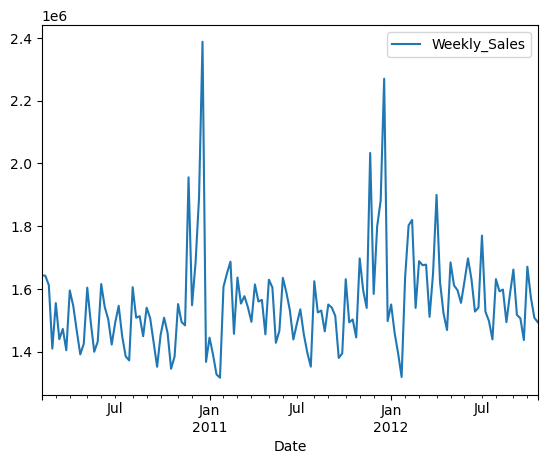

In [95]:
df4.plot()

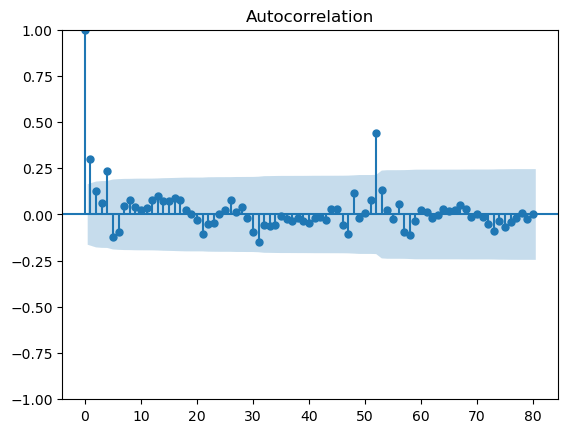

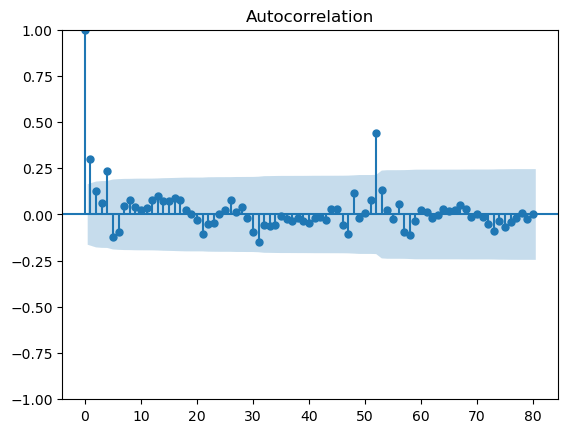

In [96]:
plot_acf(df4['Weekly_Sales'],lags=80)

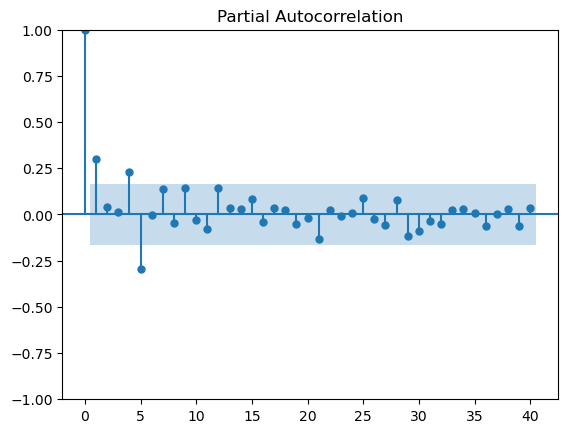

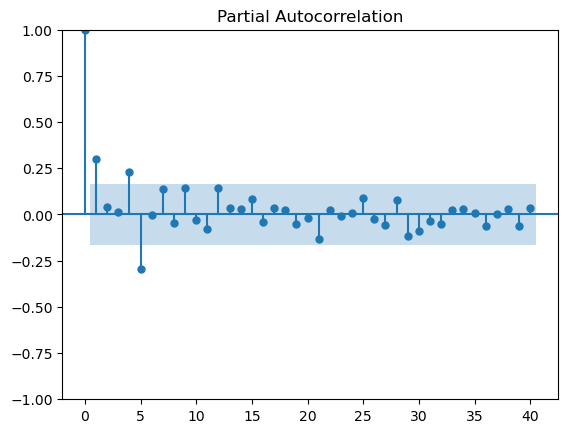

In [97]:
plot_pacf(df4['Weekly_Sales'],lags=40)

In [98]:
df4_train=df4[:114]
df4_test=df4[114:]

c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


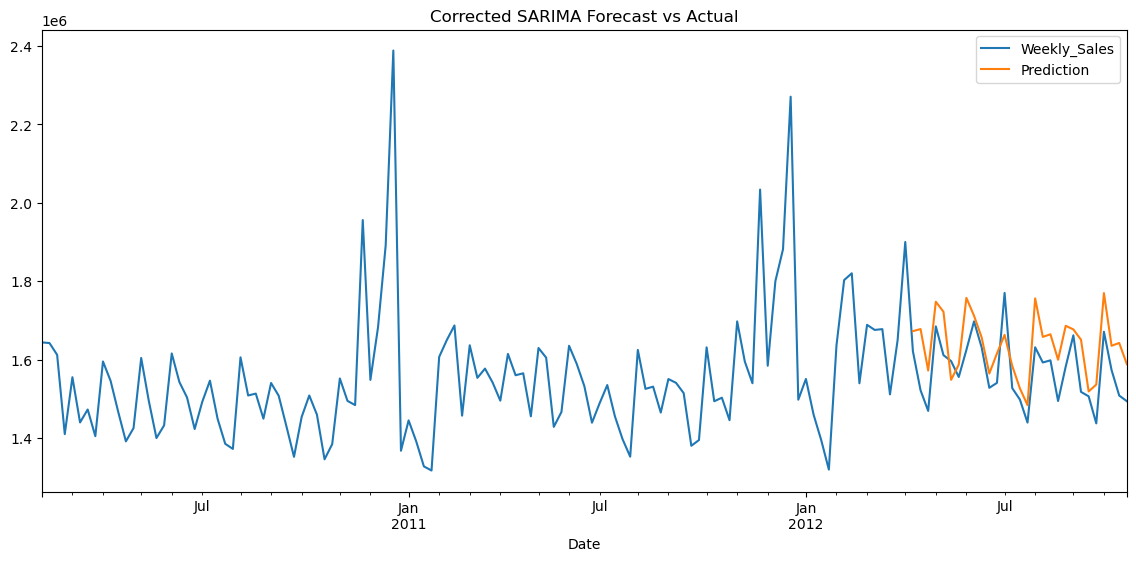

In [99]:


model = SARIMAX(df4_train,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                trend='t')

model_fit = model.fit()


start = df4_test.index[0]
end   = df4_test.index[-1]

test_predictions = model_fit.predict(start=start, end=end, dynamic=True)


df_pred = df4.copy()
df_pred["Prediction"] = None
df_pred.loc[df1_test.index, "Prediction"] = test_predictions


df_pred[['Weekly_Sales', 'Prediction']].plot(figsize=(14,6))
plt.title("Corrected SARIMA Forecast vs Actual")
plt.show()


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


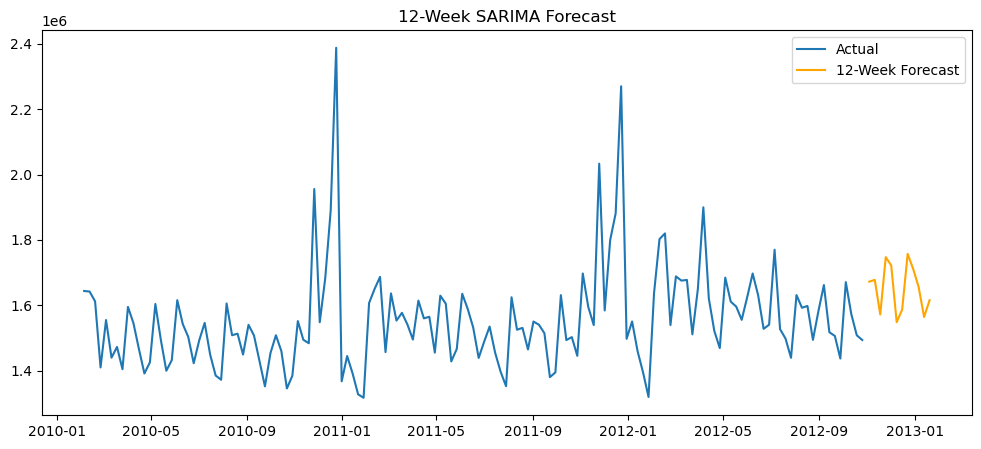

In [ ]:


models = SARIMAX(df1['Weekly_Sales'],
                order=(1,0,1),
                seasonal_order=(0,1,1,52))
models_fit = model.fit()


forecast = models_fit.forecast(steps=12)


future_dates = pd.date_range(start=df1.index[-1], periods=13, freq='W')[1:]
forecast.index = future_dates


plt.figure(figsize=(12,5))
plt.plot(df1['Weekly_Sales'], label='Actual')
plt.plot(forecast, label='12-Week Forecast', color='orange')
plt.title("12-Week SARIMA Forecast")
plt.legend()
plt.show()


Store 5

<Axes: xlabel='Date'>

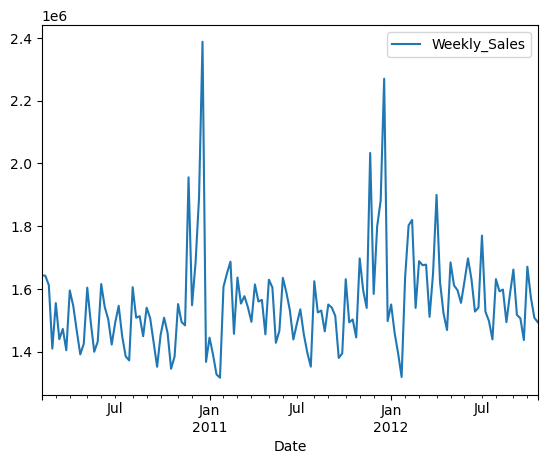

In [100]:
df5.plot()

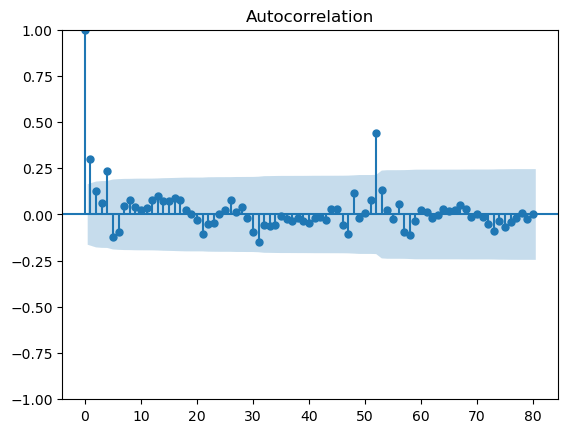

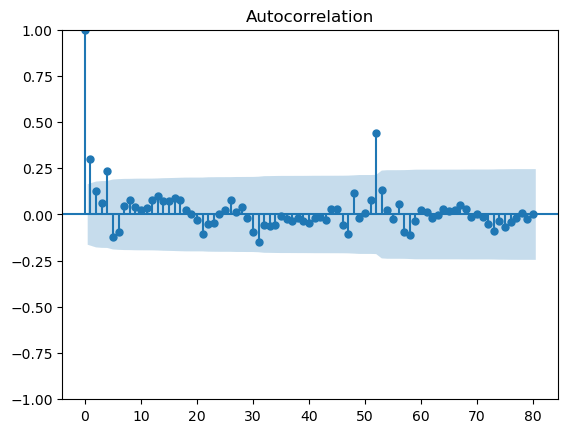

In [101]:
plot_acf(df5['Weekly_Sales'],lags=80)

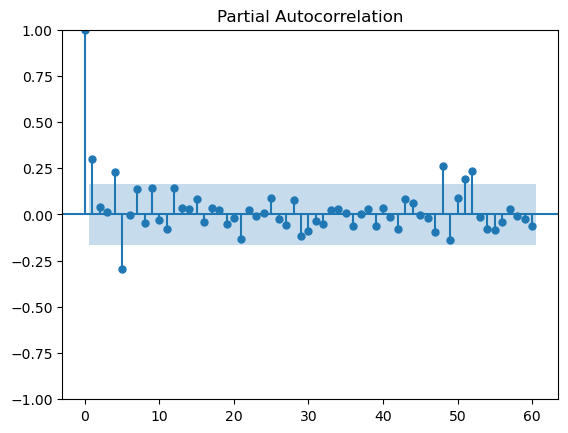

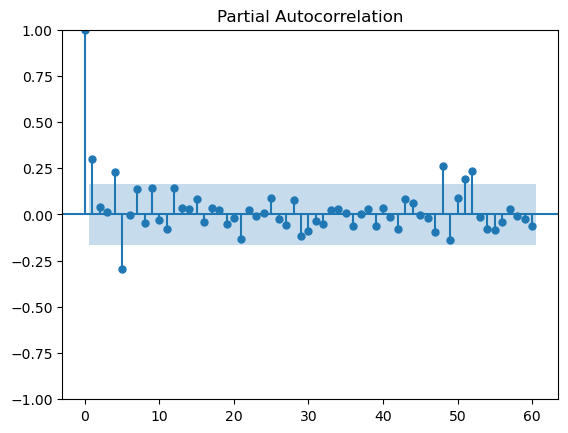

In [102]:
plot_pacf(df5['Weekly_Sales'],lags=60)

In [103]:
df5_train=df5[:114]
df5_test=df5[114:]

c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


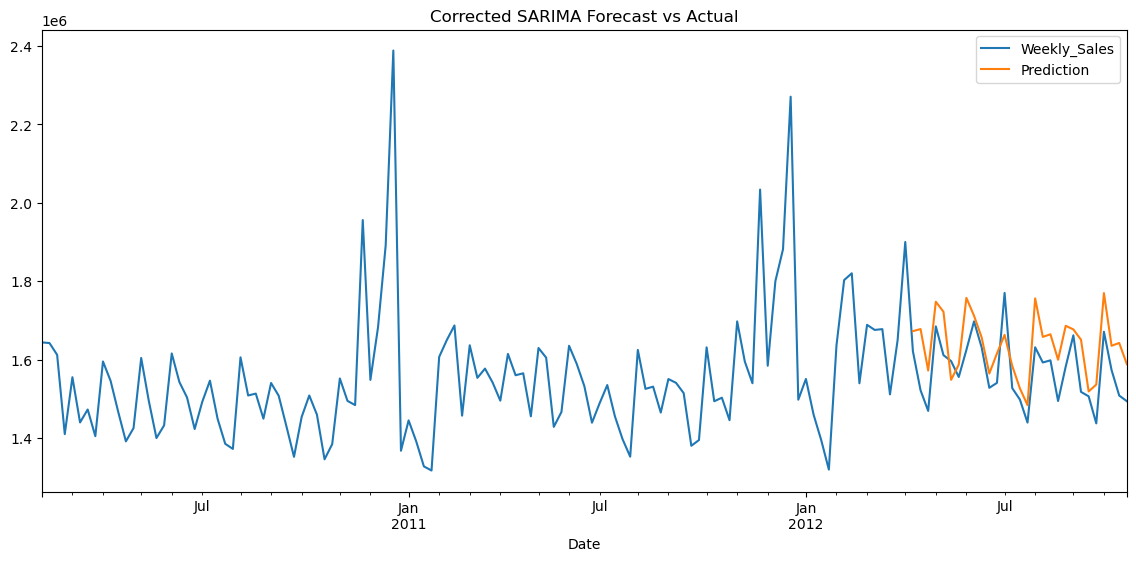

In [104]:


model = SARIMAX(df5_train,
                order=(1,0,1),
                seasonal_order=(0,1,1,52),
                trend='t')

model_fit = model.fit()


start = df5_test.index[0]
end   = df5_test.index[-1]

test_predictions = model_fit.predict(start=start, end=end, dynamic=True)


df_pred = df5.copy()
df_pred["Prediction"] = None
df_pred.loc[df1_test.index, "Prediction"] = test_predictions


df_pred[['Weekly_Sales', 'Prediction']].plot(figsize=(14,6))
plt.title("Corrected SARIMA Forecast vs Actual")
plt.show()


c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\LalithaMohan\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


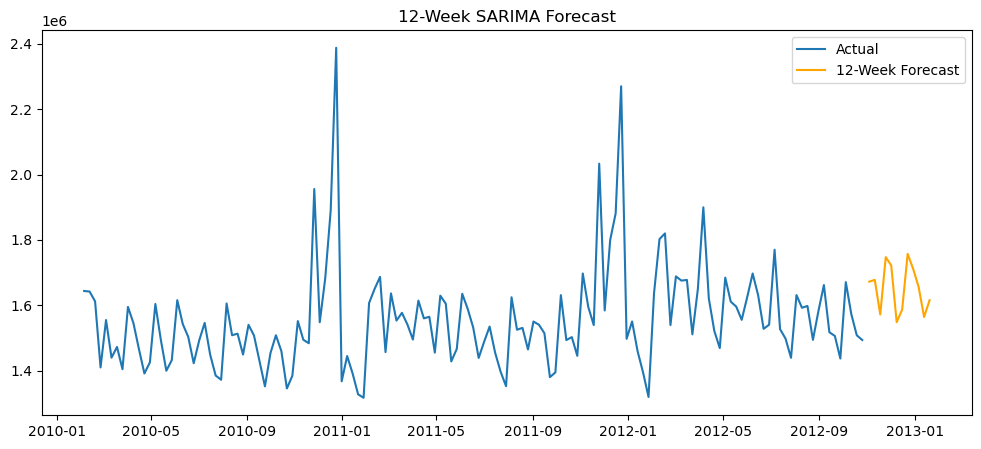

In [ ]:



models = SARIMAX(df1['Weekly_Sales'],
                order=(1,0,1),
                seasonal_order=(0,1,1,52))
models_fit = model.fit()


forecast = models_fit.forecast(steps=12)


future_dates = pd.date_range(start=df1.index[-1], periods=13, freq='W')[1:]
forecast.index = future_dates

plt.figure(figsize=(12,5))
plt.plot(df1['Weekly_Sales'], label='Actual')
plt.plot(forecast, label='12-Week Forecast', color='orange')
plt.title("12-Week SARIMA Forecast")
plt.legend()
plt.show()
